# **Task 1 – Data Preparation and Exploration (EDA)**

## **1. Load Customer Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df = pd.read_csv("customer_churn.csv")

## **2. Display**

In [ ]:
# Displaying first 10 rows
df.head(10)

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Membership_Type,Payment_Method,Preferred_Content_Type,Churn
0,1,56,35,157.957600,59,0,1,4,Standard,Debit,Movies,0
1,2,69,15,93.515499,26,0,3,1,Basic,Debit,TV Shows,0
2,3,46,25,87.095143,57,1,6,15,Premium,PayPal,Movies,1
3,4,32,28,113.986323,12,0,4,13,Standard,Credit Card,Sports,0
4,5,60,10,101.534816,11,1,5,8,Basic,Credit Card,Movies,1
5,6,25,17,166.093304,37,1,1,25,Standard,Credit Card,Sports,1
6,7,38,22,79.929269,25,0,2,4,Standard,Credit Card,Movies,1
7,8,56,26,122.738855,18,0,6,10,Basic,PayPal,Movies,1
8,9,36,25,221.841933,19,1,1,19,Standard,Debit,TV Shows,1
9,10,40,17,136.522261,23,0,5,18,Standard,Debit,Movies,1


#### **Dataset Structure**

In [ ]:
# Structure of our data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CustomerID                  1000 non-null   int64  
 1   Age                         1000 non-null   int64  
 2   Subscription_Length_Months  1000 non-null   int64  
 3   Watch_Time_Hours            1000 non-null   float64
 4   Number_of_Logins            1000 non-null   int64  
 5   Payment_Issues              1000 non-null   int64  
 6   Number_of_Complaints        1000 non-null   int64  
 7   Resolution_Time_Days        1000 non-null   int64  
 8   Membership_Type             1000 non-null   object 
 9   Payment_Method              1000 non-null   object 
 10  Preferred_Content_Type      1000 non-null   object 
 11  Churn                       1000 non-null   int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 93.9+ KB


#### **Summary Statistics**

In [ ]:
# Basic numerical stats about our data
df.describe()

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,18.218000,120.750899,30.984000,0.245000,4.552000,14.978000,0.793000
std,288.819436,14.99103,10.177822,38.583580,17.562237,0.430302,2.912349,8.394521,0.405358
min,1.000000,18.00000,1.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,250.750000,31.00000,9.000000,93.630672,16.750000,0.000000,2.000000,7.000000,1.000000
50%,500.500000,44.00000,18.000000,122.085008,31.000000,0.000000,5.000000,15.000000,1.000000
75%,750.250000,56.00000,27.000000,147.273070,47.000000,0.000000,7.000000,22.000000,1.000000
max,1000.000000,69.00000,35.000000,227.988566,59.000000,1.000000,9.000000,29.000000,1.000000


In [ ]:
# Basic categorical stats about our data
df.describe(include='object')

,Membership_Type,Payment_Method,Preferred_Content_Type
count,1000,1000,1000
unique,3,3,3
top,Standard,Debit,Movies
freq,353,347,371


## **3. Identify and handle missing values**

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
CustomerID,0
Age,0
Subscription_Length_Months,0
Watch_Time_Hours,0
Number_of_Logins,0
Payment_Issues,0
Number_of_Complaints,0
Resolution_Time_Days,0
Membership_Type,0
Payment_Method,0




> No missing values has been identified, No handling required.



## **4. Perform exploratory data analysis:**

In [ ]:
# Check for duplicate CustomerID
duplicate_customer_ids = df[df['CustomerID'].duplicated(keep=False)]

if not duplicate_customer_ids.empty:
    print(f"Found {len(duplicate_customer_ids['CustomerID'].unique())} duplicate customer IDs.")
    print("Here are the rows with duplicate CustomerIDs:")
    print(duplicate_customer_ids.sort_values(by='CustomerID'))
else:
    print("No duplicate CustomerIDs found.")

No duplicate CustomerIDs found.


In [ ]:
## Transforming categorical values into numerical values
df_encoded = pd.get_dummies(df, drop_first=True)

#### **Histogram**

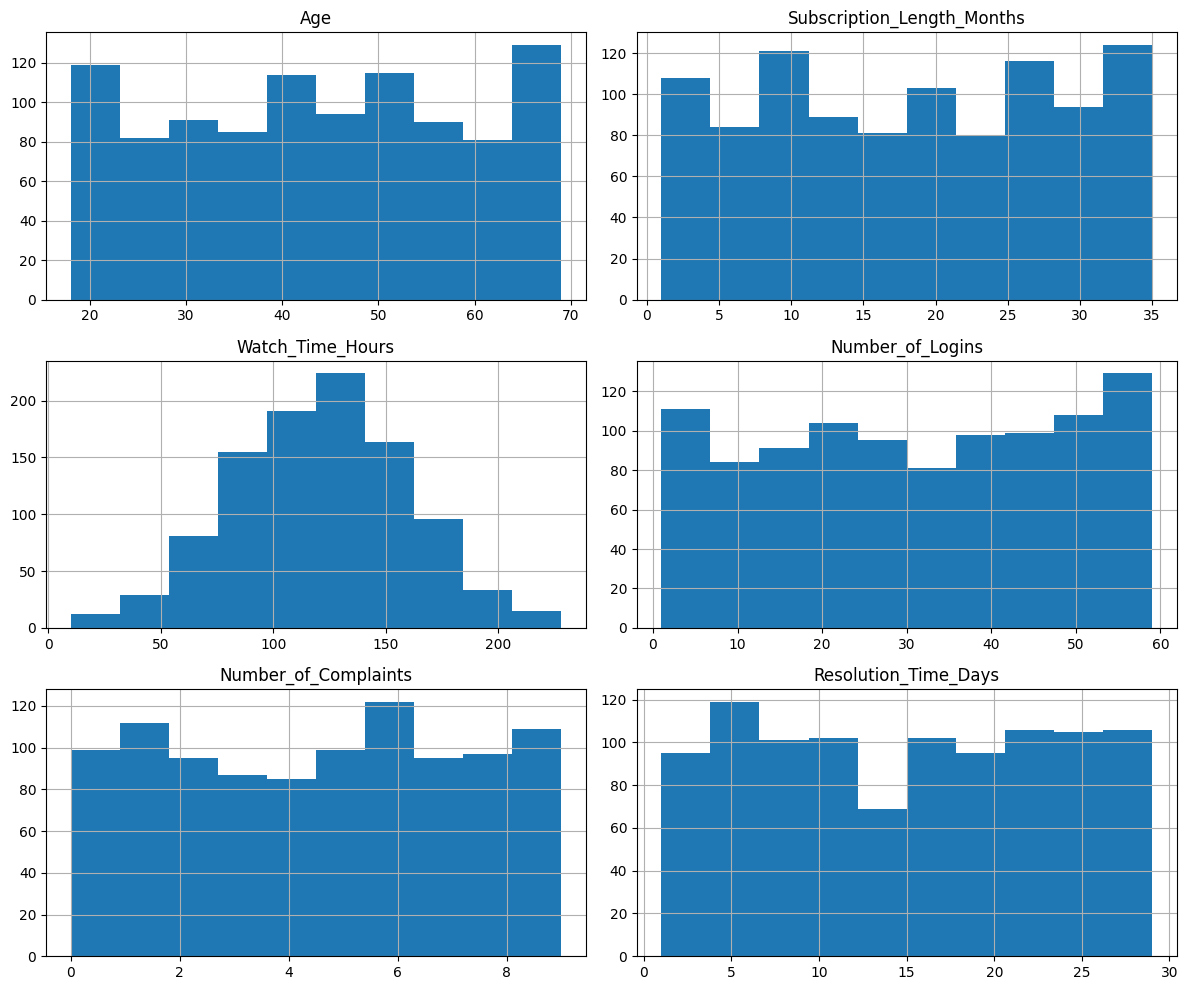

In [ ]:
columns_to_exclude = ['CustomerID', 'Churn', 'Payment_Issues']
df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

#### **Box Plots**

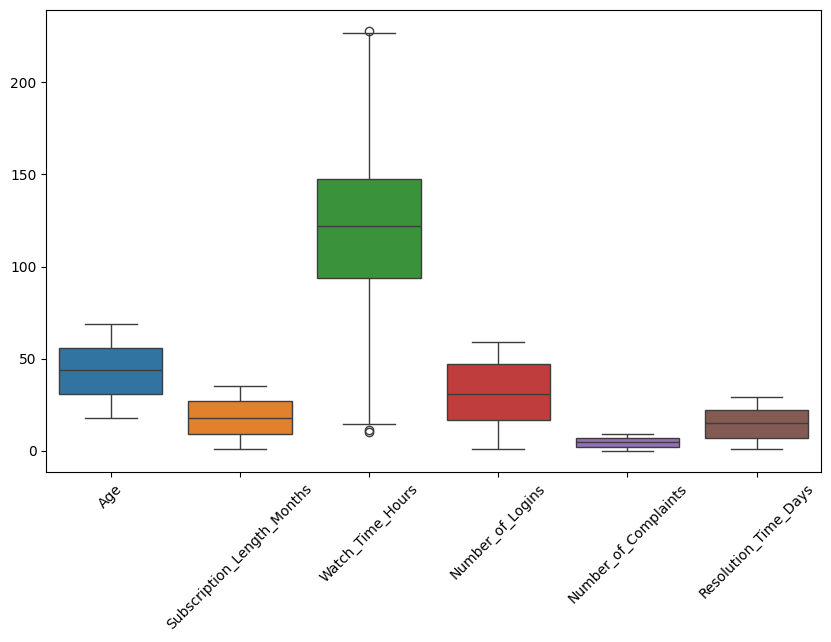

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age',
                     'Subscription_Length_Months',
                     'Watch_Time_Hours',
                     'Number_of_Logins',
                     'Number_of_Complaints',
                     'Resolution_Time_Days']])
plt.xticks(rotation=45)
plt.show()

#### **Correlation Analysis**

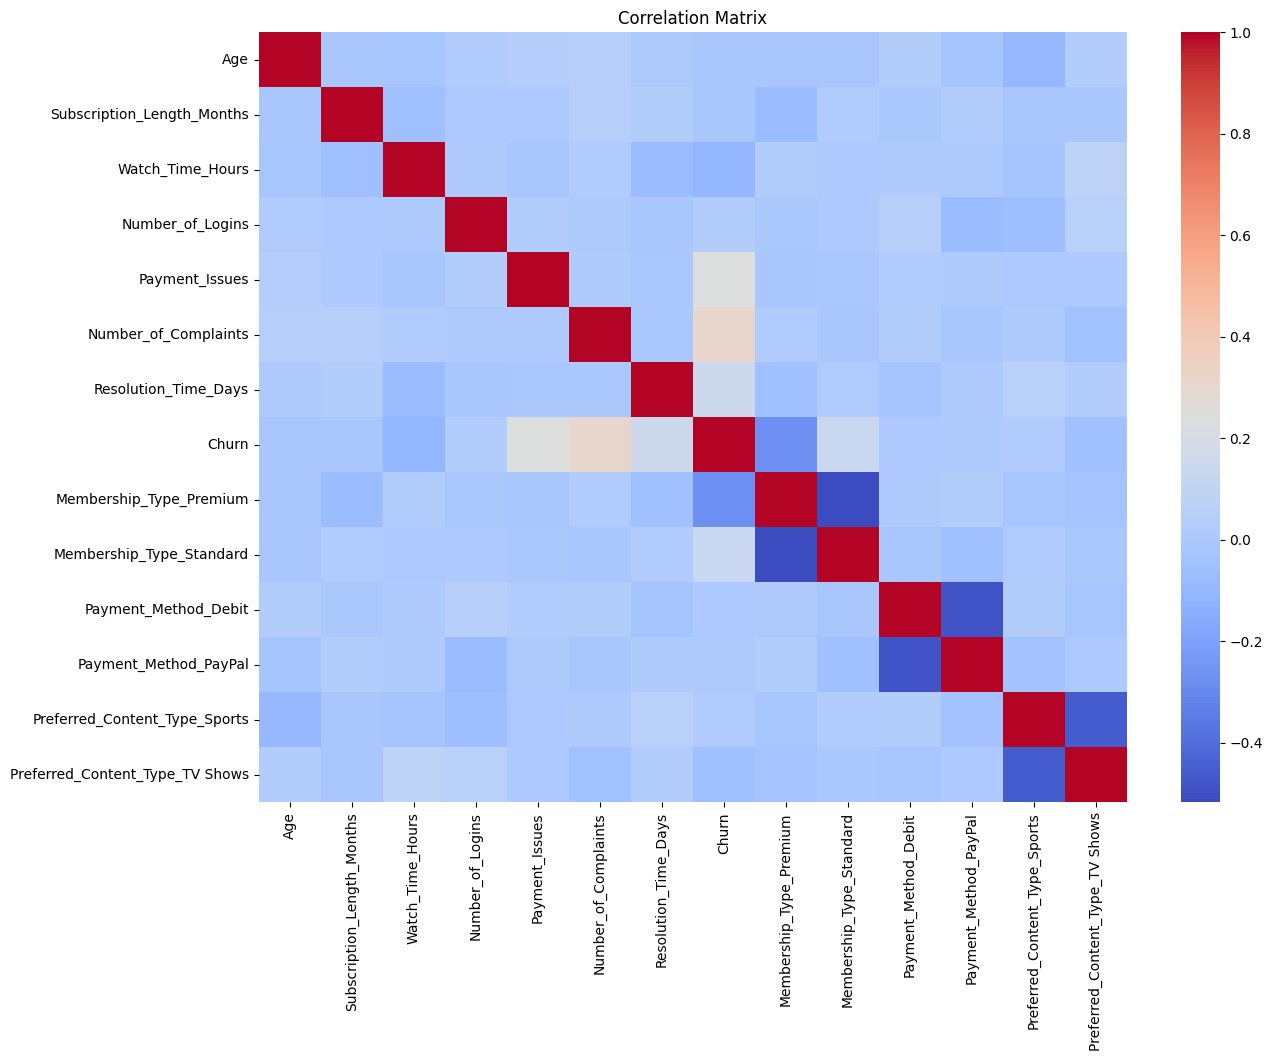

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.drop(columns=['CustomerID']).corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
churn_corr = df_encoded.corr()["Churn"].sort_values(ascending=False)
print(churn_corr)

Churn                              1.000000
Number_of_Complaints               0.310561
Payment_Issues                     0.239394
Resolution_Time_Days               0.151335
Membership_Type_Standard           0.129482
Number_of_Logins                   0.027516
Preferred_Content_Type_Sports      0.016180
Payment_Method_PayPal              0.008438
Payment_Method_Debit              -0.000887
Age                               -0.010949
Subscription_Length_Months        -0.018409
CustomerID                        -0.038351
Preferred_Content_Type_TV Shows   -0.052885
Watch_Time_Hours                  -0.105913
Membership_Type_Premium           -0.277875
Name: Churn, dtype: float64


## **5. Important patterns**






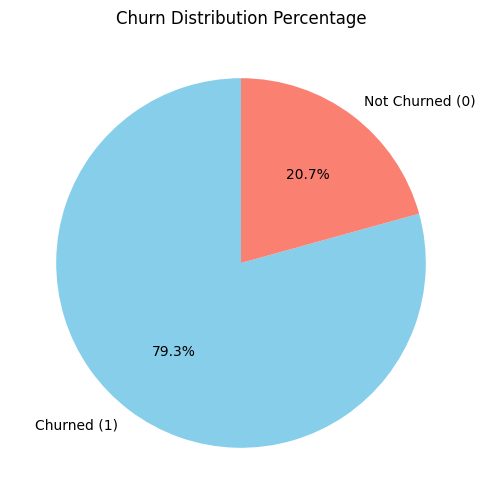

In [ ]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
plt.pie(churn_percentage, labels=['Churned (1)', 'Not Churned (0)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Churn Distribution Percentage')
plt.show()

/tmp/ipython-input-285/3586712188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_membership.index, y=churn_by_membership.values * 100, palette='viridis')


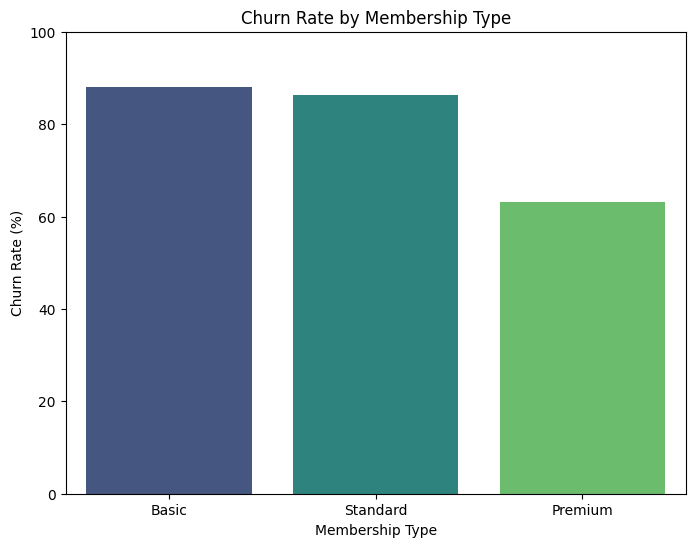

In [ ]:
churn_by_membership = df.groupby('Membership_Type')['Churn'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=churn_by_membership.index, y=churn_by_membership.values * 100, palette='viridis')
plt.title('Churn Rate by Membership Type')
plt.xlabel('Membership Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100) # Set y-axis limit to 0-100 for percentages
plt.show()

/tmp/ipython-input-285/3936562517.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_categories = df.groupby(['Age_Category', 'Complaint_Category'])['Churn'].value_counts(normalize=True).unstack().fillna(0) * 100


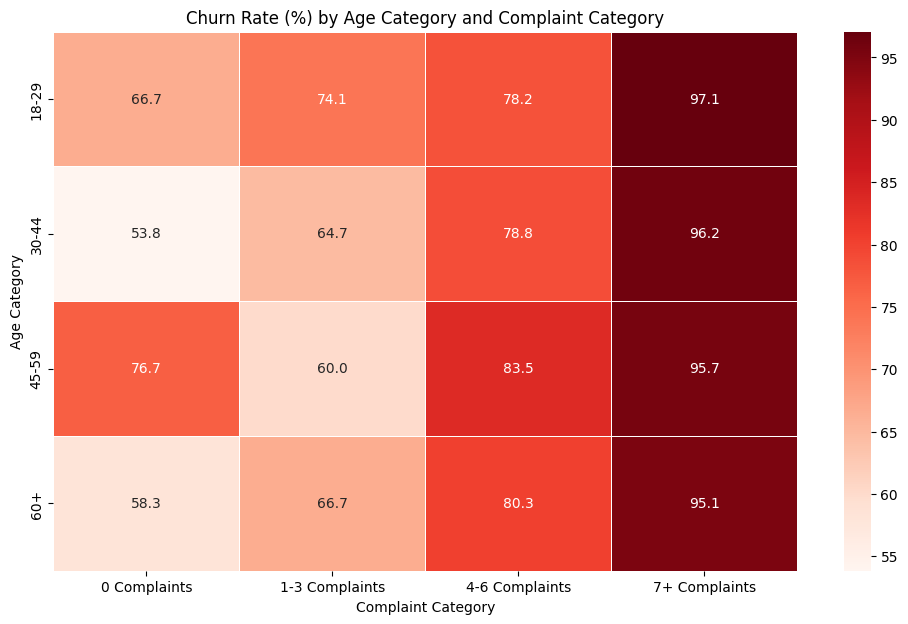

In [ ]:
age_bins = [18, 30, 45, 60, df['Age'].max() + 1]
age_labels = ['18-29', '30-44', '45-59', '60+']
df['Age_Category'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

complaint_bins = [-1, 0, 3, 6, df['Number_of_Complaints'].max() + 1]
complaint_labels = ['0 Complaints', '1-3 Complaints', '4-6 Complaints', '7+ Complaints']
df['Complaint_Category'] = pd.cut(df['Number_of_Complaints'], bins=complaint_bins, labels=complaint_labels, right=True)

churn_by_categories = df.groupby(['Age_Category', 'Complaint_Category'])['Churn'].value_counts(normalize=True).unstack().fillna(0) * 100
plt.figure(figsize=(12, 7))
sns.heatmap(churn_by_categories[1].unstack(), annot=True, fmt=".1f", cmap="Reds", linewidths=.5)
plt.title('Churn Rate (%) by Age Category and Complaint Category')
plt.ylabel('Age Category')
plt.xlabel('Complaint Category')
plt.show()

#### Churn rate and age group

- The number of complaints plays a major role in customer churn.  
- Across most age groups, customers tend to remain when no complaints are raised, except for customers aged 45–59.  
- When the number of complaints exceeds 3, more than 78% of customers across all age groups churn.  
- The situation becomes significantly worse when complaints exceed 7, with over 95% of customers churning almost immediately.

# **Task 2 – Decision Tree Classifier**

## Step 1 — In this step, we separate the independent variables (features) and the target variable (Churn).

- The `Churn` column is the target variable.
- The `CustomerID` column is removed because it is only an identifier and does not contribute to prediction.
- Since machine learning models require numerical input, categorical variables are converted into numeric form using one-hot encoding (`pd.get_dummies()`).

In [ ]:
X = df.drop(["Churn", "CustomerID"], axis=1, errors="ignore")
y = df["Churn"]

# Convert categorical columns into numeric columns
X = pd.get_dummies(X, drop_first=True)

print("Total features after encoding:", X.shape[1])
X.head()


Total features after encoding: 19


,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Membership_Type_Premium,Membership_Type_Standard,Payment_Method_Debit,Payment_Method_PayPal,Preferred_Content_Type_Sports,Preferred_Content_Type_TV Shows,Age_Category_30-44,Age_Category_45-59,Age_Category_60+,Complaint_Category_1-3 Complaints,Complaint_Category_4-6 Complaints,Complaint_Category_7+ Complaints
0,56,35,157.957600,59,0,1,4,False,True,True,False,False,False,False,True,False,True,False,False
1,69,15,93.515499,26,0,3,1,False,False,True,False,False,True,False,False,True,True,False,False
2,46,25,87.095143,57,1,6,15,True,False,False,True,False,False,False,True,False,False,True,False
3,32,28,113.986323,12,0,4,13,False,True,False,False,True,False,True,False,False,False,True,False
4,60,10,101.534816,11,1,5,8,False,False,False,False,False,False,False,False,True,False,True,False


## Step 2 — Splitting the Dataset into Training and Testing Sets

In this step, the dataset is divided into training and testing subsets.

- 80% of the data is used for training the model.
- 20% of the data is reserved for testing the model.
- `random_state=42` ensures reproducibility of results.
- `stratify=y` maintains the same proportion of churned and non-churned customers in both training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (800, 19)
Test shape: (200, 19)


## Step 3 — Training the Decision Tree Classifier (Baseline Model)

In this step, a Decision Tree Classifier is trained using the training dataset.

- `random_state=42` ensures reproducibility of the model.
- The model learns patterns from the training data to classify customers as churn (1) or non-churn (0).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Baseline Decision Tree trained")


Baseline Decision Tree trained ✅


## Step 4 — Evaluating the Baseline Decision Tree Model

In this step, the trained Decision Tree model is evaluated using the testing dataset.

The following performance metrics are calculated:

- **Accuracy**: Overall proportion of correct predictions.
- **Precision**: Proportion of correctly predicted churn cases among all predicted churn cases.
- **Recall**: Proportion of actual churn cases correctly identified by the model.
- **F1-Score**: Harmonic mean of precision and recall, providing a balanced performance measure.
- **Confusion Matrix**: Displays true positives, true negatives, false positives, and false negatives.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_base = dt.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline Precision:", precision_score(y_test, y_pred_base))
print("Baseline Recall:", recall_score(y_test, y_pred_base))
print("Baseline F1:", f1_score(y_test, y_pred_base))

print("\nClassification Report:\n", classification_report(y_test, y_pred_base))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_base))


Baseline Accuracy: 0.785
Baseline Precision: 0.8717948717948718
Baseline Recall: 0.8553459119496856
Baseline F1: 0.8634920634920635

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.51      0.49        41
           1       0.87      0.86      0.86       159

    accuracy                           0.79       200
   macro avg       0.67      0.68      0.68       200
weighted avg       0.79      0.79      0.79       200

Confusion Matrix:
 [[ 21  20]
 [ 23 136]]


## Step 5 — Hyperparameter Tuning using GridSearchCV

In this step, hyperparameter tuning is performed to improve the performance of the Decision Tree model.

The following parameters are tested:

- **max_depth**: Controls the maximum depth of the tree to prevent overfitting.
- **min_samples_split**: Minimum number of samples required to split an internal node.
- **min_samples_leaf**: Minimum number of samples required at a leaf node.

GridSearchCV performs cross-validation (cv=5) to find the best combination of parameters based on the F1-score.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_dt = grid.best_estimator_


Best Parameters: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1: 0.882041253760342


## Step 6 — Evaluating the Tuned Decision Tree Model

After identifying the optimal hyperparameters using GridSearchCV, the tuned Decision Tree model is evaluated on the test dataset.

The same performance metrics are calculated to compare the tuned model with the baseline model:

- **Accuracy**: Overall percentage of correctly classified instances.
- **Precision**: Measures how many predicted churn cases are actually churn.
- **Recall**: Measures how many actual churn cases were correctly identified.
- **F1-Score**: Balances precision and recall.
- **Confusion Matrix**: Provides detailed insight into classification performance.

In [ ]:
y_pred = best_dt.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned Precision:", precision_score(y_test, y_pred))
print("Tuned Recall:", recall_score(y_test, y_pred))
print("Tuned F1:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Tuned Accuracy: 0.79
Tuned Precision: 0.8823529411764706
Tuned Recall: 0.8490566037735849
Tuned F1: 0.8653846153846154

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.56      0.52        41
           1       0.88      0.85      0.87       159

    accuracy                           0.79       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.80      0.79      0.80       200

Confusion Matrix:
 [[ 23  18]
 [ 24 135]]


## Step 7 — Visualizing the Confusion Matrix

In this step, the confusion matrix is visualized using a heatmap to clearly display the model’s classification performance.

The confusion matrix shows:

- **True Negatives (TN)** – Correctly predicted non-churn customers  
- **True Positives (TP)** – Correctly predicted churn customers  
- **False Positives (FP)** – Customers predicted as churn but did not churn  
- **False Negatives (FN)** – Customers predicted as non-churn but actually churned  

This visualization makes it easier to interpret model performance compared to viewing raw numbers.

```python
import matplotlib.pyplot as plt

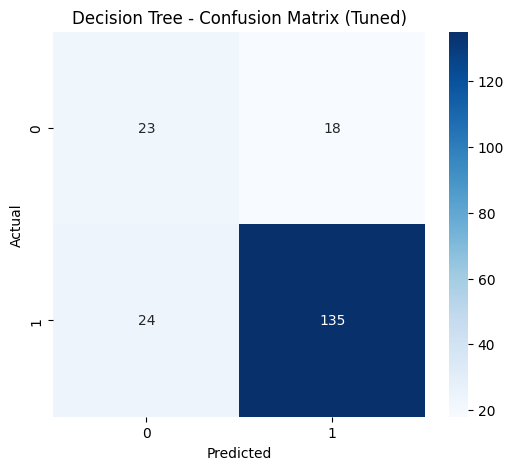

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix (Tuned)")
plt.show()


## Step 8 — Visualizing the Decision Tree Structure

In this step, the trained Decision Tree model is visualized to understand how it makes classification decisions.

The tree diagram shows:

- The features used for splitting
- The decision thresholds at each node
- The distribution of samples in each node
- The predicted class (Churn / No Churn)

To improve readability, only the top levels of the tree are displayed (`max_depth=3`).

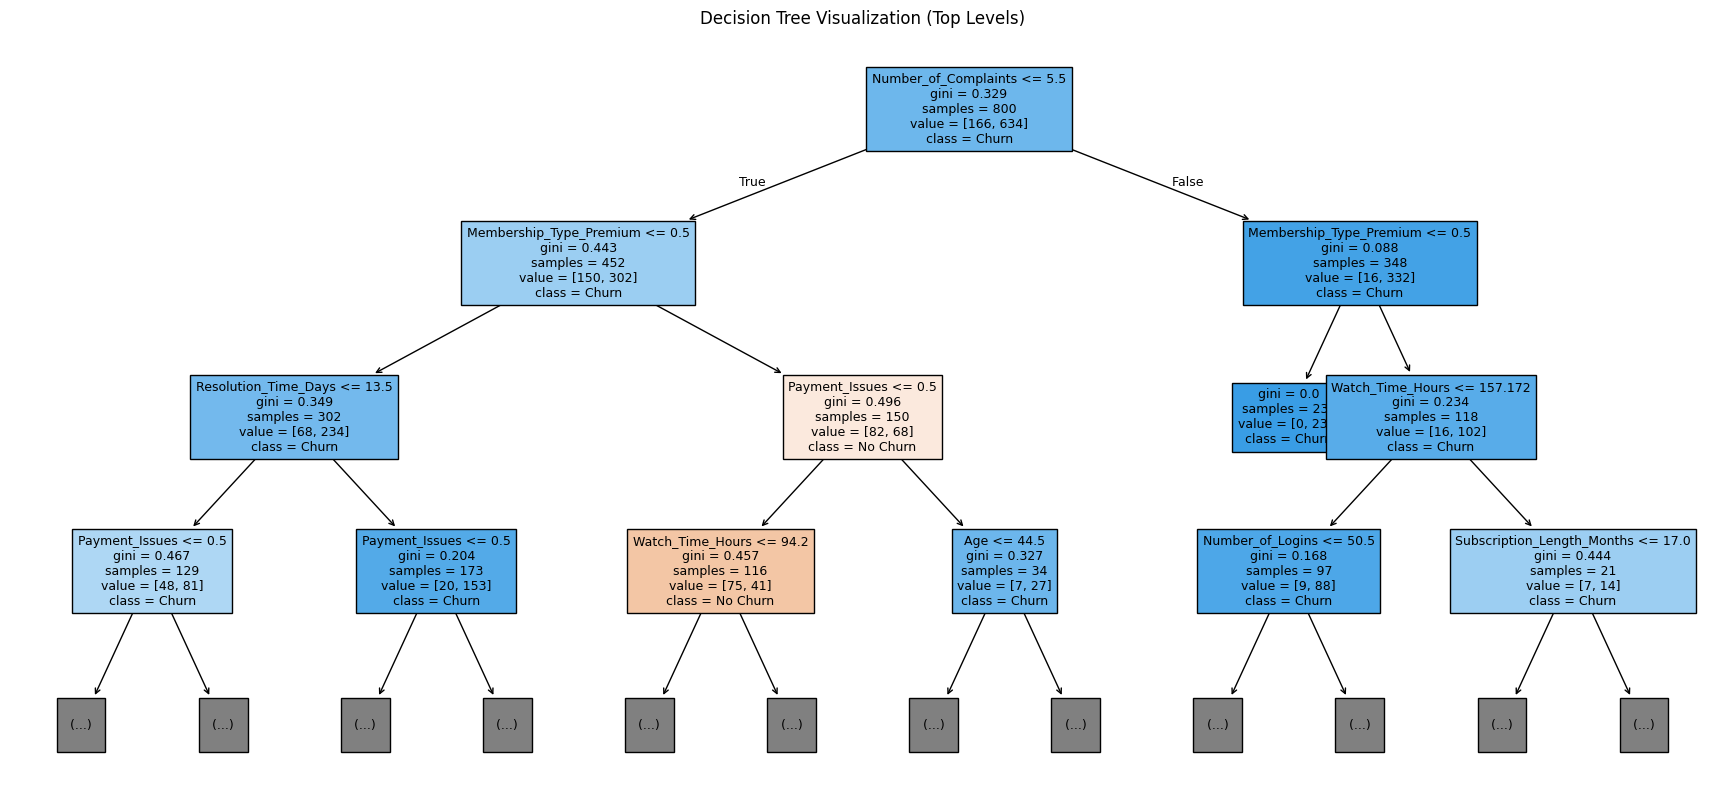

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()


## Step 9 — Analyzing Feature Importance

In this step, the importance of each feature in the Decision Tree model is analyzed.

Feature importance indicates how much each variable contributes to predicting customer churn.  
Higher importance values mean the feature plays a stronger role in decision-making within the tree.

In [ ]:
import pandas as pd

importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 15 Important Features:")
print(importances.head(15))


Top 15 Important Features:
Number_of_Complaints               0.221892
Membership_Type_Premium            0.148517
Subscription_Length_Months         0.139604
Payment_Issues                     0.131978
Resolution_Time_Days               0.127615
Watch_Time_Hours                   0.108924
Number_of_Logins                   0.067182
Age                                0.040163
Age_Category_30-44                 0.007779
Preferred_Content_Type_Sports      0.006345
Membership_Type_Standard           0.000000
Payment_Method_PayPal              0.000000
Payment_Method_Debit               0.000000
Preferred_Content_Type_TV Shows    0.000000
Age_Category_45-59                 0.000000
dtype: float64


# Task 3 – Random Forest Classifier

## Step 1 - Train a Random Forest Classifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 2.1 - Evaluating Random Forest Classifier

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_rf = rf.predict(X_test)
accuracy_score_Random_Forest = accuracy_score(y_test, y_pred_rf)
precision_score_Random_Forest = precision_score(y_test, y_pred_rf)
recall_score_Random_Forest = recall_score(y_test, y_pred_rf)
f1_score_Random_Forest = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("Accuracy Random Forest:", accuracy_score_Random_Forest)
print("Precision Random Forest:", precision_score_Random_Forest)
print("Recall:", recall_score_Random_Forest)
print("F1:", f1_score_Random_Forest)

print("\nClassification Report Random Forest:\n", classification_report(y_test, y_pred_rf))

cm_rf_Random_Forest = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix Random Forest:\n", cm_rf_Random_Forest)


Random Forest Performance
Accuracy Random Forest: 0.835
Precision Random Forest: 0.8539325842696629
Recall: 0.9559748427672956
F1: 0.9020771513353115

Classification Report Random Forest:
               precision    recall  f1-score   support

           0       0.68      0.37      0.48        41
           1       0.85      0.96      0.90       159

    accuracy                           0.83       200
   macro avg       0.77      0.66      0.69       200
weighted avg       0.82      0.83      0.81       200

Confusion Matrix Random Forest:
 [[ 15  26]
 [  7 152]]


## Step 2.2 - Comparing performance with the Descision Tree Model

In [ ]:
comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree (Tuned)": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Random Forest": [
        accuracy_score_Random_Forest,
        precision_score_Random_Forest,
        recall_score_Random_Forest,
        f1_score_Random_Forest
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Metric,Decision Tree (Tuned),Random Forest
0,Accuracy,0.790000,0.835000
1,Precision,0.882353,0.853933
2,Recall,0.849057,0.955975
3,F1-Score,0.865385,0.902077


Random Forest has a better Accuracy, Recall and F1 scores. However Decistion tree has a better Precision.
Overall Random Forest has outperfromed the Decision tree classifier in overall Perforcmance. It significantly imporver the recall score, this means that the Random Forest classifiere is more effective in identifying customers who will more likely cancel their subscriptions.

Even though the precision has dropped (ability to identify true positives), the accuracy (overall correctness) and the recall (coverage of actual postivites) makes that slight dip neglactable


## Step 3 - Analyze feature importance

We will use the the built-in feature_importance and then sort the data to know what is the most important featutres in our dataset.
The function bases it's value caluculations based on the Gini Impurity reduction.


Top 15 Important Features:
Watch_Time_Hours                     0.136653
Resolution_Time_Days                 0.119040
Number_of_Complaints                 0.117879
Subscription_Length_Months           0.108694
Number_of_Logins                     0.104348
Age                                  0.090947
Membership_Type_Premium              0.070268
Payment_Issues                       0.055267
Complaint_Category_7+ Complaints     0.037025
Complaint_Category_1-3 Complaints    0.022006
Payment_Method_Debit                 0.019191
Payment_Method_PayPal                0.018412
Preferred_Content_Type_TV Shows      0.017074
Preferred_Content_Type_Sports        0.015614
Age_Category_45-59                   0.014958
dtype: float64


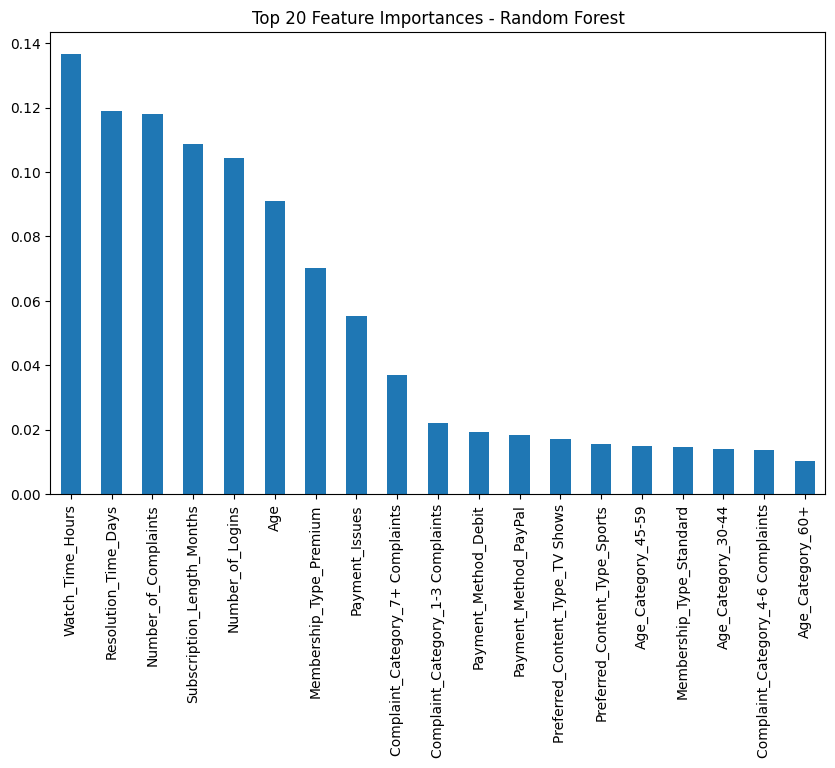

In [ ]:
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=False)

print("Top 15 Important Features:")
print(rf_importances.head(15))

# Optional visualization
plt.figure(figsize=(10,6))
rf_importances.head(20).plot(kind='bar')
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

## Step 4 - Explanation

### Which features contribute most to churn
Using Random Forest classification we can say that Watch_Time_Hours contributes the most to churn.
Afer that we get:
- Watch_Time_Hours = 0.14
- Resolution_Time_Days= 0.12
- Number_of_Complaints = 0.12
- Subscription_Length_Months = 0.11
- Number_of_Logins = 0.10
- Age = 0.09

Using this info we can say that the above factors are the most important features we can focus on to create customer retention stratgies.


### Why Random Forest may outperform a single Decision Tree

Decision tree method will use a single estimator to learn the pattern, they can be good for very specific scenarios. Decision Trees are prone to overfitting as it may learn noise and is very specific to the data set it was trained on.

However in this case Random Forests is the better choice as there are many features that need to be taken into account. Random Forest classification will build multiple desicion trees using bootstrapped samples of data. At each split a random subset of features in evaluated. This design will mitigate over fitting and will create a more reliable model. The final results will take into account multiple trees compared to contratry to the one tree using in the Decision tree model.




## **Task 4 - Business Insights and Recommendations**

## Task 4.1 - Key Factors Driving Customer Churn


Based on the feature importance analysis from the Random Forest model (Task 3), which
is used as the primary source due to its superior overall performance over the single
Decision Tree, the following factors are the most influential in predicting customer churn:

**1. Watch Time Hours (0.137)**: The strongest churn predictor according to the Random
Forest. Customers who consume less content are more likely to question the value of
their subscription and cancel. Low watch time is an early and reliable signal of
disengagement.

**2. Resolution Time in Days (0.119)**: Slow complaint resolution is the second
strongest predictor. Customers who experience long wait times for support resolution
are significantly more likely to churn, indicating that service quality directly impacts
retention.

**3. Number of Complaints (0.118)**: Closely tied with resolution time, complaint
volume is a critical churn driver. EDA findings further confirm that:
- Across most age groups, customers tend to remain when no complaints are raised,
  except for customers aged 45–59 who show elevated churn risk even without complaints
- When complaints exceed 3, over 78% of customers across all age groups churn
- When complaints exceed 7, over 95% of customers churn almost immediately

**4. Subscription Length in Months (0.109)**: Longer-tenured customers are more
likely to stay, indicating that loyalty builds over time. Newer subscribers represent
a higher churn risk and require targeted early engagement.

**5. Number of Logins (0.104)**: Less frequent platform usage signals disengagement
and correlates with higher churn risk. Together with watch time, this confirms that
low platform activity is a strong early warning sign.

**6. Age (0.091)**: Age plays a moderate but meaningful role. The Age_Category_45-59
feature also appears in the top 15 (0.015), consistent with EDA findings showing this
group churns even without complaints, suggesting different expectations or needs.

**7. Membership Type - Premium (0.070)**: Premium members are less likely to churn,
reflecting higher perceived value. While ranked lower than in the Decision Tree, it
remains a relevant factor.

**8. Payment Issues (0.055)**: Billing problems act as an additional churn trigger,
particularly when combined with other risk factors such as complaints or low engagement.

---

In summary, churn is primarily driven by low engagement (watch time and logins) and
poor support experiences (complaints and resolution time), with subscription tenure
and membership type acting as protective factors. These findings are based on the
Random Forest model, which outperforms the single Decision Tree in Accuracy, Recall,
and F1-Score, making its feature importance rankings more reliable and generalizable.

## Task 4.2 - Business Recommendations to Reduce Churn

Based on the key churn factors identified in Task 4.1, the following three concrete
recommendations are proposed for StreamFlex:

---

**Recommendation 1: Boost Content Engagement Through Personalization**

Watch_Time_Hours (0.137) and Number_of_Logins (0.104) are the strongest engagement
signals and together represent the clearest early warning signs of churn. Customers
who watch less and log in less frequently are at the highest risk of cancelling.

StreamFlex should:
- Build an automated early warning system that flags customers whose watch time
  or login frequency drops below a defined threshold
- Trigger personalized content recommendations and re-engagement campaigns for
  flagged customers, such as highlighting new releases aligned with their
  preferred content type
- Offer limited-time incentives such as a free premium trial or discounted renewal
  to re-engage at-risk customers before they cancel

---

**Recommendation 2: Overhaul Customer Support and Complaint Resolution**

Resolution_Time_Days (0.119) and Number_of_Complaints (0.118) together make customer
support the most impactful operational area for churn reduction. EDA confirms that
churn rates exceed 78% once complaints surpass 3 and reach 95% when they exceed 7,
making early intervention critical.

StreamFlex should:
- Set a strict internal resolution time target of under 13.5 days, as identified
  by the Decision Tree as the critical threshold beyond which churn probability
  rises sharply
- Flag customer accounts after their second complaint and escalate them to a
  dedicated retention team before they reach the 3 complaint threshold
- Offer proactive compensation such as service credits or free upgrades to
  dissatisfied customers to recover trust before churn occurs
- Ages 45–59 show elevated churn risk even without complaints, suggesting unmet expectations. Research this demographic to design a more personalized experience

---

**Recommendation 3: Strengthen Early Loyalty Through Onboarding and Upgrades**

Subscription_Length_Months (0.109) and Membership_Type_Premium (0.070) confirm that
newer and non-premium subscribers are at the highest churn risk, while long-tenured
and premium members are the most loyal. Payment_Issues (0.055) further adds billing
friction as an early churn trigger for new customers.

StreamFlex should:
- Design a structured onboarding program for new subscribers that drives early
  engagement, highlights platform value, and builds loyalty before churn risk peaks
- Offer time-limited discounted upgrades to premium for basic and standard members
  in their first few months, leveraging the protective effect of premium membership
  identified by the model
- Proactively address payment issues by sending early billing reminders and offering
  flexible payment options, reducing the likelihood of billing friction triggering
  early cancellation


## Task 4.3 — How the Models Supports the Recommendations


The Random Forest serves as the primary model given
its superior Recall and overall performance, while the Decision Tree complements it
with interpretable thresholds.

---

**Recommendation 1: Boost Content Engagement Through Personalization**

The Random Forest's high Recall means fewer at-risk customers go undetected, making
it reliable for powering an automated early warning system. By scoring each customer's
churn probability in real time, StreamFlex can proactively identify and target
disengaged users before they cancel rather than reacting after the fact.

---

**Recommendation 2: Overhaul Customer Support and Complaint Resolution**

The Decision Tree adds precision to this recommendation by identifying 13.5 days and
5.5 complaints as specific operational thresholds beyond which churn probability rises
sharply. These model-validated benchmarks give StreamFlex concrete targets to build
their support SLAs around, rather than relying on arbitrary internal standards.

---

**Recommendation 3: Strengthen Early Loyalty Through Onboarding and Upgrades**

The Decision Tree visually confirms that non-premium customers with high complaints
churn at significantly higher rates than premium customers in the same situation,
directly validating the upgrade incentive strategy. The model can further identify
new subscribers experiencing payment issues as a high priority segment for proactive
outreach, enabling precise and cost-effective targeting.
